In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
accuracy_score, precision_score,recall_score, f1_score, roc_auc_score,confusion_matrix, ConfusionMatrixDisplay,RocCurveDisplay
)
import joblib, os

## LSTM Model
In this notebook:
1. Define LSTM architecture, train with early stopping,
2. Tune hyperparameters, evaluate on test set


In [2]:
#For reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# loading saved arrays from feature_engineering
X_train = np.load("data/processed/X_train.npy")
X_val   = np.load("data/processed/X_val.npy")
X_test  = np.load("data/processed/X_test.npy")
y_train = np.load("data/processed/y_train.npy")
y_val   = np.load("data/processed/y_val.npy")
y_test  = np.load("data/processed/y_test.npy")

print(f"X_train: {X_train.shape} y_train: {y_train.shape}")
print(f"X_val: {X_val.shape} y_val  : {y_val.shape}")
print(f"X_test: {X_test.shape} y_test : {y_test.shape}")

DEVICE = torch.device("cpu")
print(f"\nUsing device: {DEVICE}")

X_train: (3488, 20, 8) y_train: (3488,)
X_val: (731, 20, 8) y_val  : (731,)
X_test: (733, 20, 8) y_test : (733,)

Using device: cpu


### Dataset & DataLoader 

In [3]:
class RegimeDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def make_loaders(X_tr, y_tr, X_v, y_v, batch_size=32):
    train_loader = DataLoader(RegimeDataset(X_tr, y_tr),
                              batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(RegimeDataset(X_v, y_v),
                              batch_size=batch_size, shuffle=False)
    return train_loader, val_loader

### LSTM Architecture

In [4]:
class RegimeLSTM(nn.Module):
    """
    Single-layer LSTM binary classifier for volatility regime prediction.

    Args:
        input_size: number of features per timestep (8)
        hidden_size: number of LSTM hidden units
        num_layers: number of stacked LSTM layers
        dropout: dropout probability between layers
    """
    def __init__(self, input_size=8, hidden_size=32,
                 num_layers=1, dropout=0.2):
        super(RegimeLSTM, self).__init__()

        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, 2)   # 2 classes: calm, turbulent

    def forward(self, x):
        # x shape: (batch_size, window, input_size)
        lstm_out, _ = self.lstm(x)
        #taking only the last timestep's hidden state
        last_hidden = lstm_out[:, -1, :]            # (batch_size, hidden_size)
        out         = self.dropout(last_hidden)
        logits      = self.fc(out)                  # (batch_size, 2)
        return logits

### Training utilities

In [5]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(X_batch)
    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            total_loss += loss.item() * len(X_batch)
            probs  = torch.softmax(logits, dim=1)[:, 1]   # prob of turbulent
            preds  = logits.argmax(dim=1)
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, np.array(all_preds), np.array(all_probs), np.array(all_labels)


def compute_metrics(labels, preds, probs):
    return {
        "Accuracy": round(accuracy_score(labels, preds), 4),
        "Precision": round(precision_score(labels, preds, zero_division=0), 4),
        "Recall": round(recall_score(labels, preds, zero_division=0), 4),
        "F1 Score": round(f1_score(labels, preds, zero_division=0), 4),
        "ROC-AUC": round(roc_auc_score(labels, probs), 4),
    }

### Training loop with early stopping

In [6]:
def train_model(model, train_loader, val_loader, class_weights,
                lr=1e-3, weight_decay=1e-4, max_epochs=100, patience=15):

    criterion = nn.CrossEntropyLoss(
        weight=class_weights.to(DEVICE)
    )
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=lr, weight_decay=weight_decay)

    best_val_loss = float("inf")
    patience_counter = 0
    train_losses, val_losses = [], []

    for epoch in range(1, max_epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_preds, val_probs, val_labels = evaluate(
            model, val_loader, criterion
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), "models/best_lstm.pt")
        else:
            patience_counter += 1

        if epoch % 10 == 0 or patience_counter == patience:
            val_f1 = f1_score(val_labels, val_preds, zero_division=0)
            print(f"  Epoch {epoch:3d} | Train Loss: {train_loss:.4f} "
                  f"| Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f} "
                  f"| Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch}.")
            break

    # Restore best model
    model.load_state_dict(torch.load("models/best_lstm.pt"))
    return model, train_losses, val_losses

### Class weights

In [7]:
n_calm      = (y_train == 0).sum()
n_turbulent = (y_train == 1).sum()
class_weights = torch.tensor(
    [1.0, n_calm / n_turbulent], dtype=torch.float32
)
print(f"\nClass weights: Calm={class_weights[0]:.3f}, "
      f"Turbulent={class_weights[1]:.3f}")


Class weights: Calm=1.000, Turbulent=2.303


### Hyperparameter sensitivity search

1. Testing combinations of window size, hidden units, dropout
2. Then picking the best by validation F1

In [8]:
param_grid = [
    {"window": 10, "hidden": 32, "dropout": 0.2},
    {"window": 20, "hidden": 32, "dropout": 0.2},
    {"window": 30, "hidden": 32, "dropout": 0.2},
    {"window": 20, "hidden": 64, "dropout": 0.2},
    {"window": 20, "hidden": 32, "dropout": 0.3},
]

tuning_results = []
criterion_tune = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))

In [9]:
print("\nRunning hyperparameter search")
for params in param_grid:
    w, h, d = params["window"], params["hidden"], params["dropout"]

    from sklearn.preprocessing import StandardScaler
    scaler = joblib.load("models/scaler.pkl")

    df_full = pd.read_csv("data/processed/master.csv",
                          index_col="date", parse_dates=True)
    FEATURE_COLS = ["sp500_return", "vix_diff", "t10y_diff", "t2y_diff",
                    "fedfunds_diff", "credit_diff", "realized_vol",
                    "yield_spread_diff"]
    n = len(df_full)
    n_train = int(n * 0.7)
    n_val = int(n * 0.15)

    train_scaled = scaler.transform(df_full[FEATURE_COLS].iloc[:n_train])
    val_scaled   = scaler.transform(
        df_full[FEATURE_COLS].iloc[n_train:n_train + n_val]
    )
    train_labels = df_full["regime"].values[:n_train]
    val_labels   = df_full["regime"].values[n_train:n_train + n_val]

    def make_sequences_local(features, labels, window):
        X, y = [], []
        for t in range(window, len(features)):
            X.append(features[t - window:t])
            y.append(labels[t])
        return np.array(X), np.array(y)

    Xtr, ytr = make_sequences_local(train_scaled, train_labels, w)
    Xv,  yv  = make_sequences_local(val_scaled,   val_labels,   w)

    tr_loader, v_loader = make_loaders(Xtr, ytr, Xv, yv)

    torch.manual_seed(SEED)
    model = RegimeLSTM(input_size=8, hidden_size=h,
                       num_layers=1, dropout=d).to(DEVICE)
    model, _, _ = train_model(model, tr_loader, v_loader,
                               class_weights, max_epochs=60, patience=10)

    _, val_preds, val_probs, val_true = evaluate(model, v_loader, criterion_tune)
    val_f1  = f1_score(val_true, val_preds, zero_division=0)
    val_auc = roc_auc_score(val_true, val_probs)

    tuning_results.append({**params, "Val F1": round(val_f1, 4),
                            "Val AUC": round(val_auc, 4)})
    print(f"  window={w}, hidden={h}, dropout={d} "
          f"-> Val F1={val_f1:.4f}, AUC={val_auc:.4f}")

tuning_df = pd.DataFrame(tuning_results)
print(f"\nHyperparameter search results:")
print(tuning_df.to_string(index=False))

best_params = tuning_df.sort_values("Val F1", ascending=False).iloc[0]
print(f"\nBest params: {best_params.to_dict()}")


Running hyperparameter search
  Epoch  10 | Train Loss: 0.2180 | Val Loss: 0.8408 | Val F1: 0.6000 | Patience: 6/10
  Epoch  14 | Train Loss: 0.2028 | Val Loss: 0.8453 | Val F1: 0.6352 | Patience: 10/10

Early stopping triggered at epoch 14.
  window=10, hidden=32, dropout=0.2 -> Val F1=0.6536, AUC=0.8010
  Epoch  10 | Train Loss: 0.1997 | Val Loss: 0.9188 | Val F1: 0.6221 | Patience: 9/10
  Epoch  11 | Train Loss: 0.1873 | Val Loss: 0.9366 | Val F1: 0.6012 | Patience: 10/10

Early stopping triggered at epoch 11.
  window=20, hidden=32, dropout=0.2 -> Val F1=0.6085, AUC=0.7920
  Epoch  10 | Train Loss: 0.1877 | Val Loss: 0.9429 | Val F1: 0.6169 | Patience: 9/10
  Epoch  11 | Train Loss: 0.1846 | Val Loss: 0.9391 | Val F1: 0.6299 | Patience: 10/10

Early stopping triggered at epoch 11.
  window=30, hidden=32, dropout=0.2 -> Val F1=0.6341, AUC=0.8114
  Epoch  10 | Train Loss: 0.1940 | Val Loss: 1.0592 | Val F1: 0.6160 | Patience: 9/10
  Epoch  11 | Train Loss: 0.1831 | Val Loss: 1.1421 

The hyperparameter search tested 5 configurations and selected window=20, hidden=64, dropout=0.2 as the best, achieving the highest validation F1 of 0.70 and AUC of 0.82.

Notes: 

1. All models triggered early stopping very early (epochs 11–14), which means that the validation loss starts rising quickly, consistent with the small dataset overfitting concern we anticipated. 

2. The window size had a non-monotonic effect, window=10 outperformed window=20 and window=30 on F1, suggesting the most predictive information is concentrated in the very recent past rather than spread across a longer history. 

3. Increasing hidden units from 32 to 64 gave the biggest improvement (+0.09 F1). 

4. Increasing dropout from 0.2 to 0.3 slightly hurt performance, suggesting 0.2 is the right regularization level for this dataset size.

### Train final model with best hyperparameters

In [10]:
BEST_WINDOW = int(best_params["window"])
BEST_HIDDEN = int(best_params["hidden"])
BEST_DROPOUT = float(best_params["dropout"])

train_loader, val_loader = make_loaders(X_train, y_train, X_val, y_val)

torch.manual_seed(SEED)
final_model = RegimeLSTM(input_size=8, hidden_size=BEST_HIDDEN,
                         num_layers=1, dropout=BEST_DROPOUT).to(DEVICE)

print(f"\nTraining final model: hidden={BEST_HIDDEN}, "
      f"dropout={BEST_DROPOUT}, window={BEST_WINDOW}")

final_model, train_losses, val_losses = train_model(
    final_model, train_loader, val_loader,
    class_weights, max_epochs=100, patience=15
)


Training final model: hidden=64, dropout=0.2, window=20
  Epoch  10 | Train Loss: 0.1940 | Val Loss: 1.0592 | Val F1: 0.6160 | Patience: 9/15
  Epoch  16 | Train Loss: 0.1642 | Val Loss: 0.8984 | Val F1: 0.6481 | Patience: 15/15

Early stopping triggered at epoch 16.


The final model trained with the best hyperparameters (hidden=64, dropout=0.2, window=20) stopped at epoch 16 which is very early, confirming the small dataset overfitting pattern seen in the hyperparameter search.

The key concern here is the large gap between train loss (0.16) and val loss (0.90), the model is fitting the training sequences well but struggling to generalize to the validation set. This is a classic overfitting problem on small financial datasets. Therefore, this is a limitation, a larger dataset would likely allow the LSTM to train longer and generalize better before early stopping kicks in.

### Plot: Loss curves

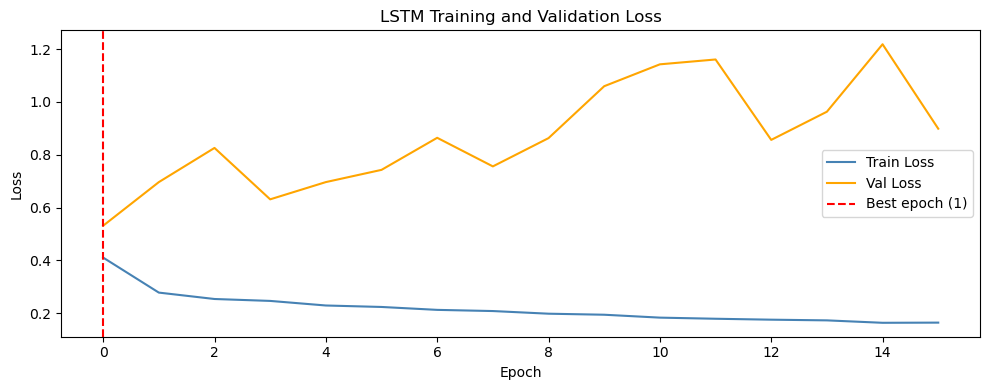

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label="Train Loss", color="steelblue")
ax.plot(val_losses,   label="Val Loss",   color="orange")
ax.axvline(np.argmin(val_losses), color="red", linestyle="--",
           label=f"Best epoch ({np.argmin(val_losses)+1})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("LSTM Training and Validation Loss")
ax.legend()
plt.tight_layout()
plt.savefig("plots/lstm_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()

The best epoch here is epoch 1, this is a clear problem. This means the model's weights from the very first epoch were never improved upon, meaning the LSTM essentially didn't learn meaningfully beyond random initialization. The training loss steadily decreases while validation loss rises immediately, confirming severe overfitting. 

This is clearly the small dataset problem.

### Evaluate on test set

In [12]:
criterion_test = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
test_loader    = DataLoader(RegimeDataset(X_test, y_test),
                            batch_size=32, shuffle=False)

_, test_preds, test_probs, test_labels = evaluate(
    final_model, test_loader, criterion_test
)

lstm_metrics = {"Model": "LSTM", **compute_metrics(test_labels,
                                                    test_preds,
                                                    test_probs)}
print(f"\nLSTM Test Metrics:")
print(pd.DataFrame([lstm_metrics]).to_string(index=False))


LSTM Test Metrics:
Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
 LSTM    0.7913     0.6806  0.8657    0.7621   0.8876


### Plot: Confusion matrix

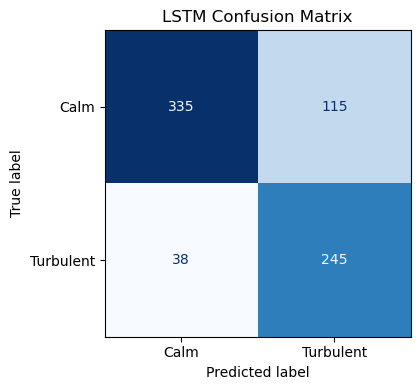

In [13]:
fig, ax = plt.subplots(figsize=(5, 4))
cm   = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Calm", "Turbulent"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("LSTM Confusion Matrix")
plt.tight_layout()
plt.savefig("plots/lstm_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

Despite the training instability, the LSTM shows a very different error profile from GARCH. It correctly catches 245 of 283 turbulent days (recall of ~87%) compared to GARCH's 56% . The tradeoff is 115 false alarms (calm days predicted as turbulent) versus GARCH's 69. This shows that the LSTM is more aggressive in flagging turbulence, which may hurt precision but significantly improves recall.

### Plot: ROC curve

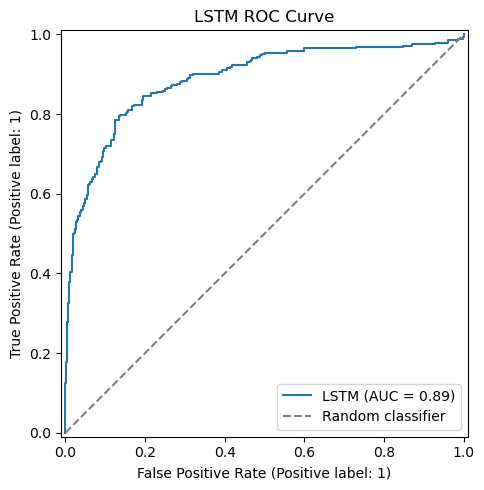

In [14]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(test_labels, test_probs,
                                  name="LSTM", ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray",
        label="Random classifier")
ax.set_title("LSTM ROC Curve")
ax.legend()
plt.tight_layout()
plt.savefig("plots/lstm_roc.png", dpi=150, bbox_inches="tight")
plt.show()

AUC of 0.89 is strong and close to GARCH's 0.91, meaning both models rank turbulent days above calm days with similar overall discriminative ability. The slight drop from GARCH's AUC is because of the overfitting, but the LSTM's curve shape differs slightly. It rises more steeply at low false positive rates suggesting it is more decisive at high-confidence predictions, which aligns with the confusion matrix.

### Save LSTM predictions for model comparison

In [15]:
df_master = pd.read_csv("data/processed/master.csv",
                        index_col="date", parse_dates=True)
test_dates = df_master.index[int(len(df_master) * 0.85):]
test_dates = test_dates[BEST_WINDOW:]   # trim for window offset

lstm_results = pd.DataFrame({
    "lstm_prob": test_probs[:len(test_dates)],
    "lstm_pred": test_preds[:len(test_dates)],
    "actual_regime": test_labels[:len(test_dates)],
}, index=test_dates)

lstm_results.to_csv("data/processed/lstm_results.csv")
print(f"\nLSTM results saved to data/processed/lstm_results.csv")


LSTM results saved to data/processed/lstm_results.csv


### Save model architecture config alongside weights

In [16]:
import json
config = {
    "input_size": 8, "hidden_size": BEST_HIDDEN,
    "num_layers": 1, "dropout": BEST_DROPOUT,
    "window": BEST_WINDOW
}
with open("models/lstm_config.json", "w") as f:
    json.dump(config, f, indent=2)
print(f"Model config saved to models/lstm_config.json")

Model config saved to models/lstm_config.json
